In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import numpy as np

Dados carregados com sucesso! Total de linhas: 500


In [8]:
df_maze = pd.read_csv('/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/mazes.csv')

arquivos = {
    'BFS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_bfs.csv',
    'DFS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_dfs.csv',
    'UCS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_ucs.csv',
    'Gulosa': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_guloso.csv',
    'A*': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_a_star.csv',
}

dfs = []
for nome_algoritmo, caminho_arquivo in arquivos.items():
    try:
        df_temp = pd.read_csv(caminho_arquivo)
        df_temp['Algoritmo'] = nome_algoritmo
        
        df_temp['Execucao'] = df_temp.index + 1 
        
        
        # for i, row in df_astar.iterrows():
        #     listOnOff.append((row['custo_online'] / row['custo']))

        dfConcat = pd.concat([df_temp, df_maze['cicles'], df_maze['width'], df_maze['length'], df_maze['start'], df_maze['end']], axis=1)

        dfs.append(dfConcat)
    except FileNotFoundError:
        print(f"Atenção: O arquivo {caminho_arquivo} não foi encontrado.")

df_completo = pd.concat(dfs, ignore_index=True)
print("Dados carregados com sucesso! Total de linhas:", len(df_completo))

,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,Algoritmo,Execucao,cicles,width,length,start,end
0,68c9aa7d-d049-449e-9bee-578f7a5946c2,True,120,121,1850,1850,0.002731,"[(1, 1), (2, 1), (3, 1), (3, 2), (4, 2), (5, 2...",BFS,1,0.165014,59,59,"(1, 1)","(57, 57)"
1,4365687c-6081-4ef6-8cff-25ceae5fa678,True,38,39,202,206,0.000302,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3...",BFS,2,0.356110,13,31,"(1, 1)","(11, 29)"
2,365a746f-0149-4c69-a8db-150d0a4b7772,True,160,161,278,278,0.000429,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",BFS,3,0.017423,9,71,"(1, 1)","(7, 69)"
3,2685d2bd-85dd-4aa9-ae4e-b07dd1de4555,True,124,125,193,193,0.000309,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2...",BFS,4,0.133721,5,93,"(1, 1)","(3, 91)"
4,7cbfee4c-33f0-4596-8ba1-0f03cb731697,True,176,177,5073,5073,0.008450,"[(1, 1), (1, 2), (2, 2), (3, 2), (3, 3), (4, 3...",BFS,5,0.479754,93,89,"(1, 1)","(91, 87)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5545,c4eeca5d-5e81-45cb-b707-90b332300b67,True,96,97,951,58,0.001929,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",A*,1106,0.443401,61,41,"(1, 1)","(59, 39)"
5546,f7f922d8-cedb-4b8e-b498-d4f7e9d802ca,True,30,31,37,4,0.000114,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3...",A*,1107,0.098560,11,17,"(1, 1)","(9, 15)"
5547,b5446596-be4e-4f9d-8436-4743ad4df3bf,True,122,123,1407,73,0.002970,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",A*,1108,0.203904,45,65,"(1, 1)","(43, 63)"
5548,524754e0-4025-44cc-9498-79e3822ad895,True,28,29,63,5,0.000158,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",A*,1109,0.347685,7,27,"(1, 1)","(5, 25)"


In [2]:
# Filtra apenas as colunas numéricas/booleanas que importam para a tabela
colunas = ['sucesso', 'custo', 'passos', 'expandidos', 'fronteira', 'tempo_segundos']

ordem = ['BFS', 'DFS', 'UCS', 'Gulosa', 'A*']
df_completo['Algoritmo'] = pd.Categorical(df_completo['Algoritmo'], categories=ordem, ordered=True)

df_completo

,Algoritmo,sucesso,custo,passos,expandidos,fronteira,tempo_segundos
0,BFS,100%,134,135,1528,1531,0.0015
1,DFS,100%,294,295,657,738,0.0010
2,UCS,100%,134,135,1695,1698,0.0020
3,Gulosa,100%,157,158,199,236,0.0003
4,A*,100%,134,135,979,52,0.0013


/tmp/ipykernel_2126334/93338684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico1 = sns.barplot(data=df_medias, x='Algoritmo', y='expandidos', palette='viridis')


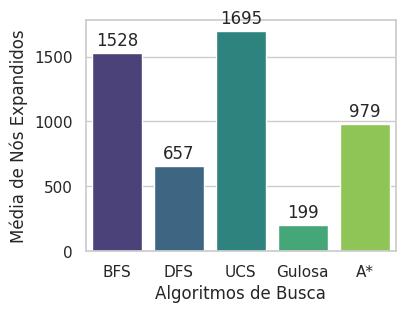

/tmp/ipykernel_2126334/93338684.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico2 = sns.barplot(data=df_medias, x='Algoritmo', y='custo', palette='rocket')


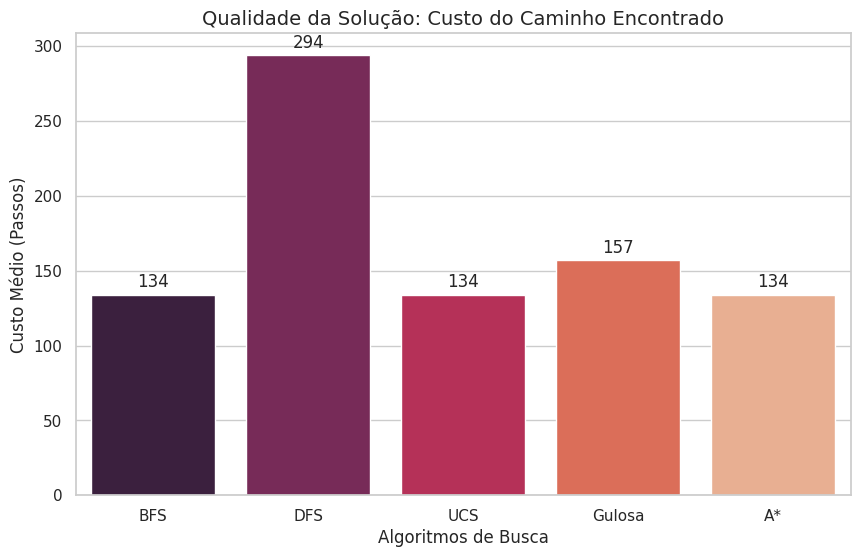

In [13]:
# 1. Configuração de Pesos (Ajuste conforme a prioridade do seu trabalho)
alpha, beta, gamma, delta, epsilon = 1.0, 0.01, 10.0, 5.0, 2.0

# --- GRÁFICO 1: Eficiência Computacional (Nós Expandidos) ---
plt.figure(figsize=(4, 3))
grafico1 = sns.barplot(data=df_medias, x='Algoritmo', y='expandidos', palette='viridis')
# plt.title('Eficiência Computacional: Nós Expandidos por Algoritmo', fontsize=14)
plt.ylabel('Média de Nós Expandidos', fontsize=12)
plt.xlabel('Algoritmos de Busca', fontsize=12)

df_full = df_completo.copy()
df_full['start_tupla'] = df_full['start'].apply(converter_string_para_tupla)
df_full['end_tupla'] = df_full['end'].apply(converter_string_para_tupla)

# Cálculo da Distância Euclidiana
df_full['distancia_euclidiana'] = df_full.apply(
    lambda row: np.sqrt((row['end_tupla'][0] - row['start_tupla'][0])**2 + 
                        (row['end_tupla'][1] - row['start_tupla'][1])**2), axis=1
)

# Cálculo da Área
df_full['area'] = df_full['width'] * df_full['length']

# 3. Cálculo do Score com todas as métricas disponíveis
# Garantimos que colunas faltantes (se houver) sejam tratadas como 0
df_full['celulas_revisitadas'] = df_full.get('celulas_revisitadas', 0)
df_full['replanejamentos'] = df_full.get('replanejamentos', 0)

# Aplicando a fórmula: Custo + (custo_expandindo + tempo + mov_inv + revisita)
# Invertemos os sinais de penalidade para que o valor final seja positivo
df_full['score'] = (
    (alpha * df_full['custo']) +
    (beta * df_full['expandidos']) + 
    (gamma * df_full['tempo_segundos']) + 
    (delta * df_full['replanejamentos']) + 
    (epsilon * df_full['celulas_revisitadas'])
)

# 4. Visualização
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_full,
    x='distancia_euclidiana', 
    y='score',
    hue='Algoritmo',
    size='area', 
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)

# Opcional: Escala logarítmica no Y se o score variar ordens de grandeza
plt.yscale('log') 

plt.xlabel('Distância Euclidiana (Complexidade Geográfica)', fontsize=12)
plt.ylabel('performance', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Algoritmo & Área')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()